In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


This below cell is only for me as I am running in collab. Evaluator don't need to run it


In [128]:
df = pd.read_csv("titanic.csv")

In [129]:
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True)*100)

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [148]:
features = ["pclass","sex","age","sibsp","parch","fare","embarked"]
X = df[features]
y = df["survived"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Full output proportion:\n",y.value_counts(normalize=True))
print("\n")
print("Training proportion:\n",y_train.value_counts(normalize=True))
print("\n")
print("Testing proportion:\n",y_test.value_counts(normalize=True))

Full output proportion:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Training proportion:
 survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


Testing proportion:
 survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


### Stratified Train Test Split

If we see the survived and not survived classes are not exactly balanced, so I used stratify while splitting the data.

Due to using stratify we are getting the test and trian porportion of classes same as original dataset.

In [131]:
numeric_cols = ["pclass","age","sibsp","parch","fare"]
categorical_cols = ["sex","embarked"]
numeric_processor = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_processor = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",drop="first"))])
preprocessor = ColumnTransformer([("numeric",numeric_processor,numeric_cols),("categoricl",categorical_processor,categorical_cols)])


### Preprocessing

I used median imputation and StandardScaler for numerical columns because scaler about making sure all columns are in similar scale so it is used for numerical columns.

For categorical columns I used most frequent imputation and OneHotEncoder.

The preprocessing is done inside a ColumnTransformer and will be fitted only when the model pipeline is fitted on `X_train`. The test data is only transformed using the preprocessing learned from training data, so test data information does not leak into training.

In [132]:
logistic_pipeline = Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000))])
logistic_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categoricl',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [133]:
tree_pipeline = Pipeline([("preprocessor",preprocessor),("model",DecisionTreeClassifier(random_state=42))])
tree_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categoricl',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

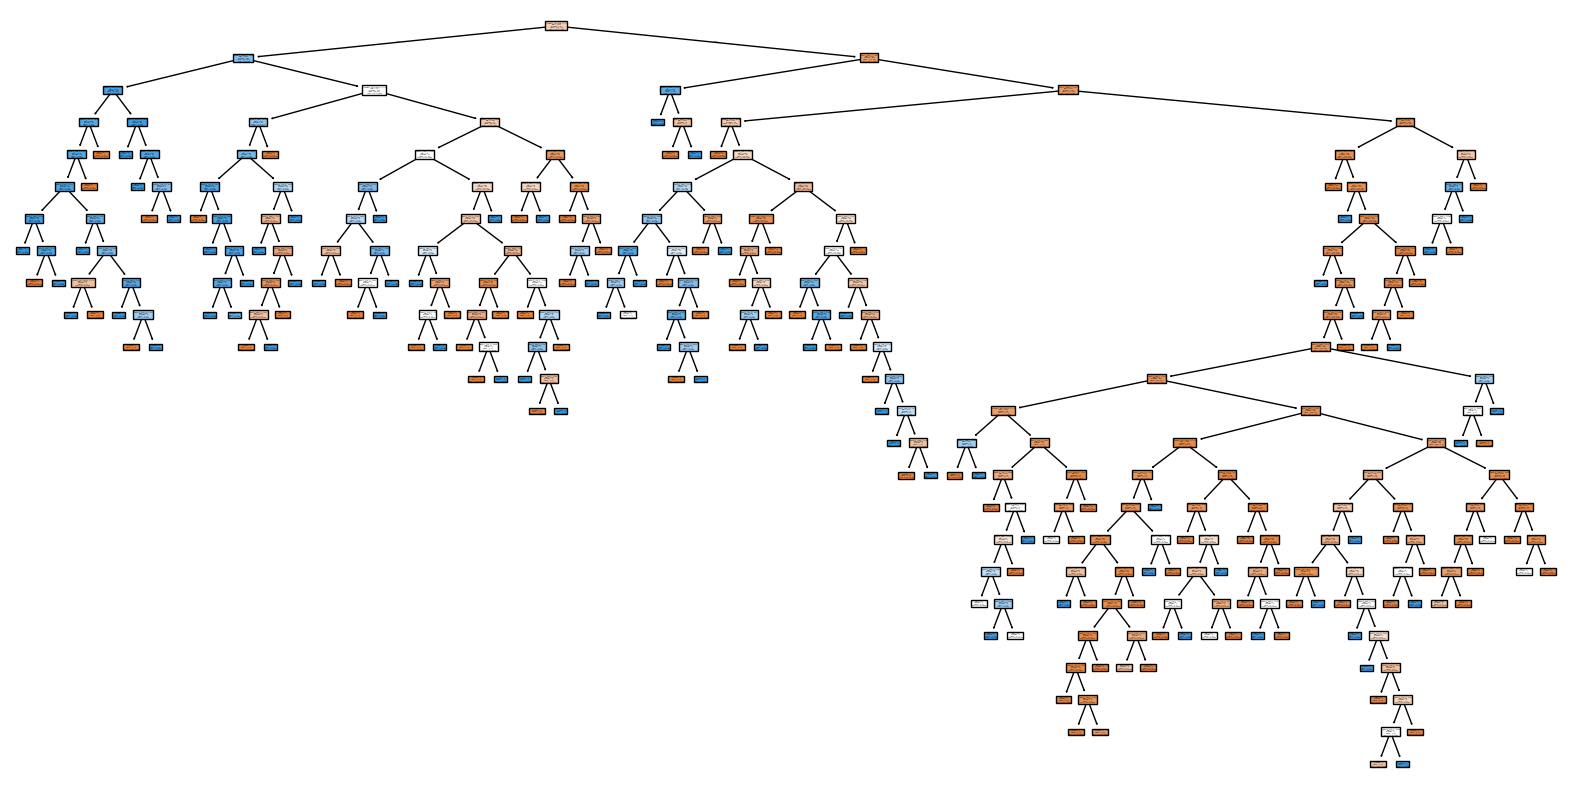

In [134]:
feature_names= tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
plt.figure(figsize=(20,10))
plot_tree(tree_pipeline.named_steps["model"],feature_names=feature_names,class_names=["Not Survived", "Survived"],filled=True)
plt.show()

In [135]:
rf_pipeline = Pipeline([("preprocessor",preprocessor),("model",RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categoricl',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [136]:
models = {"Logistic Regression": logistic_pipeline, "Decision Tree": tree_pipeline, "Random Forest": rf_pipeline}
results = []
for name, model in models.items():
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:,1]
  results.append([name, accuracy_score(y_test,y_pred), precision_score(y_test,y_pred), recall_score(y_test,y_pred), f1_score(y_test,y_pred), roc_auc_score(y_test,y_prob)])
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
results_df


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843478
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.791436
2,Random Forest,0.810056,0.769231,0.724638,0.746269,0.830171


### Classification Model Comparison


Decision Tree has the highest accuracy of 0.821 and F1 score of 0.758. Logistic Regression has the highest AUC of 0.843 and slightly higher precision of 0.793.

Decision Tree and Random Forest have the highest recall of 0.725. Overall, Decision Tree performed better across most of the main classification metrics.

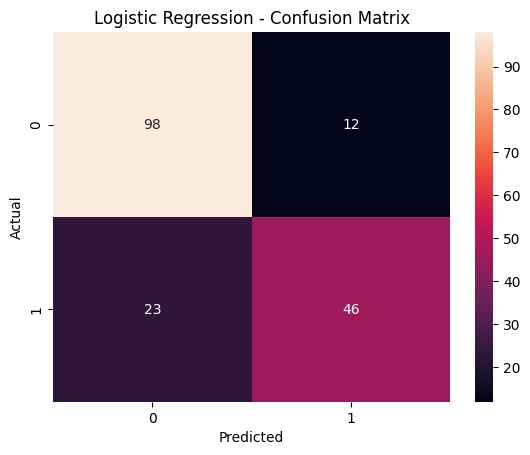

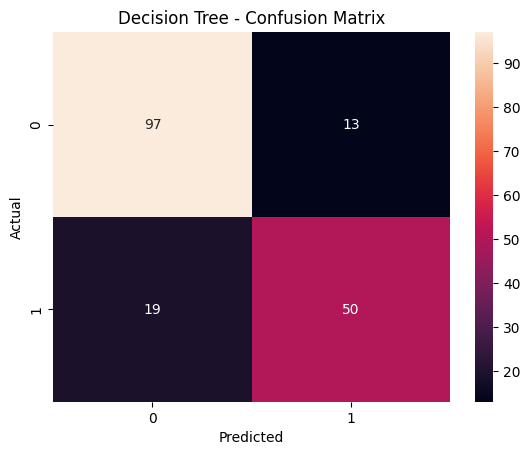

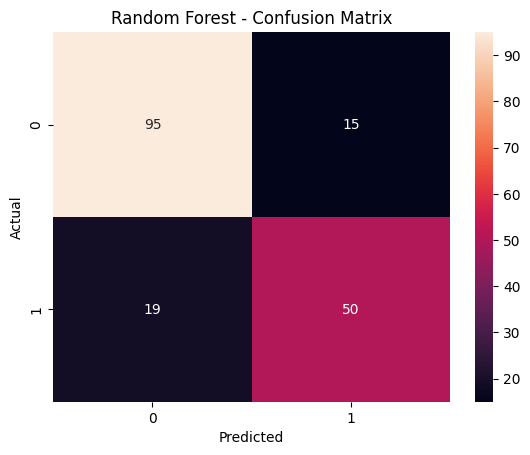

In [137]:
for name, model in models.items():
  y_pred = model.predict(X_test)
  sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)
  plt.title(f"{name} - Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

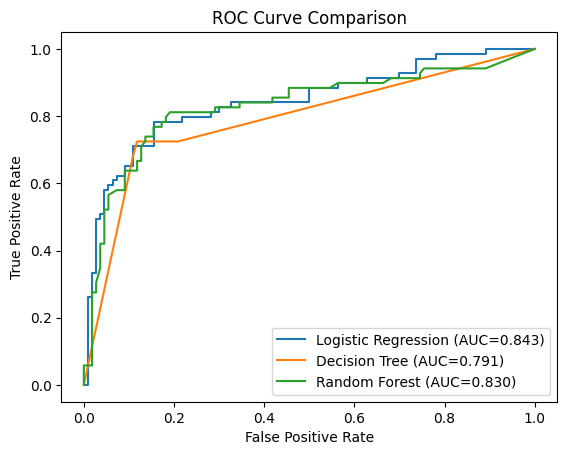

In [138]:
for name, model in models.items():
  y_prob = model.predict_proba(X_test)[:,1]
  fpr, tpr, threshold = roc_curve(y_test,y_prob)
  plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y_test,y_prob):.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### ROC Curve Comparison


Logistic Regression has the highest AUC of 0.843, followed by Random Forest with 0.830 and Decision Tree with 0.791.

This shows that Logistic Regression has better ability to separate survived and not survived passengers compared to the other two models.

#IMBALANCE

In [139]:
print("Initial Imabalnce:\n")
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True)*100)
print("\n\n")
baseline_model = Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000))])
baseline_model.fit(X_train,y_train)
balanced_model = Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000,class_weight="balanced"))])
balanced_model.fit(X_train,y_train)
smote_model = ImbPipeline([("preprocessor",preprocessor),("smote",SMOTE(random_state=42)),("model",LogisticRegression(max_iter=1000))])
smote_model.fit(X_train,y_train)
imbalance_models = {"Baseline":baseline_model,"Class Weight":balanced_model,"SMOTE":smote_model}
imbalance_results = []

for name,model in imbalance_models.items():
  y_pred = model.predict(X_test)
  imbalance_results.append([name,precision_score(y_test,y_pred),recall_score(y_test,y_pred),f1_score(y_test,y_pred)])
imbalance_df = pd.DataFrame(imbalance_results,columns=["Method","Precision","Recall","F1"])
imbalance_df

Initial Imabalnce:

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64





,Method,Precision,Recall,F1
0,Baseline,0.793103,0.666667,0.724409
1,Class Weight,0.729730,0.782609,0.755245
2,SMOTE,0.739726,0.782609,0.760563


### Imbalance Handling Comparison

The dataset has 61.62% not survived and 38.38% survived passengers, so there is some class imbalance.

Baseline has the highest precision of 0.793. Class Weight and SMOTE both have the highest recall of 0.783, while SMOTE has the highest F1 score of 0.761.

So I would choose SMOTE among the three methods because it gives the best F1 score and improves recall compared to the baseline model.

#TUNING

In [140]:
rf_OOB = Pipeline([("preprocessor",preprocessor),("model",RandomForestClassifier(random_state=42,oob_score=True))])
grid = {"model__n_estimators":[50,100,200],"model__max_depth":[5,10,20,None],"model__max_features":["sqrt","log2"]}
grid_search = GridSearchCV(rf_OOB,grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('categoricl',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'embarked'])])),
                                       ('model',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 20, None],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [141]:
print("Best Parameters:",grid_search.best_params_)
print("Best CV Score:",grid_search.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__max_features': 'log2', 'model__n_estimators': 50}
Best CV Score: 0.8245346203092684


In [142]:
print("OOB SCORE BEST:", grid_search.best_estimator_.named_steps["model"].oob_score_)
print("best features: ",grid_search.best_estimator_.named_steps["model"].feature_importances_)
print("max depth: ",grid_search.best_estimator_.named_steps["model"].max_depth)
print("max features: ",grid_search.best_estimator_.named_steps["model"].max_features)
print("n estimators: ", grid_search.best_estimator_.named_steps["model"].n_estimators)


OOB SCORE BEST: 0.827247191011236
best features:  [0.15445656 0.12652899 0.04453253 0.02656629 0.15562082 0.45534224
 0.0073447  0.02960785]
max depth:  5
max features:  log2
n estimators:  50


### Random Forest Hyperparameter Tuning

I used GridSearchCV to find the best combination of n_estimators, max_depth and max_features for Random Forest.

The best parameters are n_estimators = 50, max_depth = 5 and max_features = log2. The OOB score of the best Random Forest model is 0.827.

#REGRESSION

In [143]:
X_reg = df[["survived","pclass","sex","age","sibsp","parch","embarked"]]
y_reg = df["fare"]
X_train_reg,X_test_reg,y_train_reg,y_test_reg = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)
num_reg = ["survived","pclass","age","sibsp","parch"]
cat_reg = ["sex","embarked"]
reg_preprocessor = ColumnTransformer([("num",numeric_processor,num_reg),("cat",categorical_processor,cat_reg)])
reg_pipeline = Pipeline([("preprocessor",reg_preprocessor),("model",LinearRegression())])
reg_pipeline.fit(X_train_reg,y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg,y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg,y_pred_reg))
r2 = r2_score(y_test_reg,y_pred_reg)
n = len(y_test_reg)
p = reg_pipeline.named_steps["preprocessor"].get_feature_names_out().shape[0]
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)

In [144]:
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)
print("Adjusted R2:",adjusted_r2)

MAE: 20.897717925140874
RMSE: 30.532802561398345
R2: 0.39754802380221577
Adjusted R2: 0.36919734256937886


### Regression Model Evaluation

The Linear Regression model has MAE of 20.898 and RMSE of 30.533. The R2 score is 0.398, which means the model explains around 39.8% of the variation in fare.

The Adjusted R2 is 0.369, which is slightly lower than R2 because it also considers the number of features used in the model.

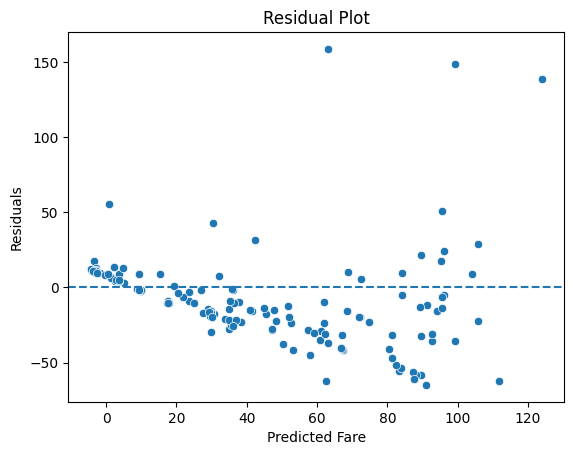

In [145]:
residuals = y_test_reg-y_pred_reg
sns.scatterplot(x=y_pred_reg,y=residuals)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows heteroscedasticity because the residuals are not randomly spread around zero. As the predicted fare increases, the residual values are more spread out. There are also some very large positive residuals for higher fare values.

In [146]:
regression_table = pd.DataFrame({
    "Model":["Linear Regression"],
    "MAE":[mae],
    "RMSE":[rmse],
    "R2":[r2],
    "Adjusted R2":[adjusted_r2]
})

print("Regression Table: \n",regression_table)
print("\n\n")
print("Classification Table: \n",results_df)

Regression Table: 
                Model        MAE       RMSE        R2  Adjusted R2
0  Linear Regression  20.897718  30.532803  0.397548     0.369197



Classification Table: 
                  Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843478
1        Decision Tree  0.821229   0.793651  0.724638  0.757576  0.791436
2        Random Forest  0.810056   0.769231  0.724638  0.746269  0.830171


### Final Recommendation

Decision Tree performed better overall compared to Logistic Regression and Random Forest.

It has the highest accuracy of 0.821, precision of 0.794 and F1 score of 0.758. Decision Tree and Random Forest have the highest recall of 0.725, while Logistic Regression has the highest AUC of 0.843.

So I would choose Decision Tree as the final classifier because it performed better across most of the main classification metrics.

### Regression Result

The Linear Regression model got an MAE of 20.898 and RMSE of 30.533. The R2 score is 0.398 and Adjusted R2 score is 0.369, which means the model explains around 39.8% of the variation in fare.

The residual plot shows heteroscedasticity because the residuals are not evenly spread around zero. As the predicted fare increases, the residual values become more spread out. There are also some large residual values at higher predicted fares.

In [149]:
best_pipeline = tree_pipeline
joblib.dump(best_pipeline,"best_pipeline.joblib")
loaded_pipeline = joblib.load("best_pipeline.joblib")
sample = X_test.iloc[:20]
print("Original:",best_pipeline.predict(sample))
print("Reloaded:",loaded_pipeline.predict(sample))

Original: [0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1]
Reloaded: [0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1]


My loaded pipeline and best pipeline which is Decision Tree giving the same result means I have saved the model properly and it can reloaded and use it on raw data without the need of train and all those things